# **Forecasting Glucose Levels in Type 1 Diabetes Using Time-Series Approaches**

**Student Name:** Muhammad Umer Mehmood  
**Student ID:** 23102319  
**Supervisor:** Ralf Napiwotzki

---

## **About the Dataset**

The **GlucoBench** repository provides extensive longitudinal Continuous Glucose Monitoring (CGM) records. Each row represents a single glucose measurement from a specific patient at a specific timestamp. The dataset integrates glucose readings with clinical, lifestyle, and demographic information.

**Key Features:**
- **Core:** Patient ID (`id`), Blood Glucose (`gl` — target variable, mg/dL), Timestamp (`time`)
- **Demographics:** Gender, Race, Education Level, Annual Income, Marital Status
- **Clinical History:** T1D Diagnosis Age, Comorbidities (Hypertension, Neuropathy, CKD, etc.)
- **Lifestyle:** Exercise Frequency, Alcohol Consumption
- **Medications:** Binary indicators for common prescriptions (Aspirin, Statins, etc.)

**Data Source:** [GlucoBench](https://github.com/IrinaStatsLab/GlucoBench)

---

## **Research Question**

> *Can deep learning models (LSTM, GRU, and CNN) accurately forecast blood glucose levels 30 minutes ahead using CGM data from Type 1 Diabetes patients?*

## **Objectives**

1. Build and train three deep learning models (LSTM, GRU, CNN) for 30-minute-ahead glucose forecasting.
2. Evaluate and compare model performance using MAE, RMSE, and R² metrics.
3. Identify the most accurate and clinically reliable model for blood glucose forecasting.

# **1. Environment Setup**

In [1]:
# =====================================================
# IMPORTS & CONFIGURATION
# =====================================================

# --- Core ---
import numpy as np
import pandas as pd
import warnings
import random
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & Metrics ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Statistical Tests ---
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, GRU, Conv1D, MaxPooling1D,
                                      Dense, Dropout, Flatten,
                                      BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print(" All libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")
print(f"   NumPy version:      {np.__version__}")
print(f"   Pandas version:     {pd.__version__}")

✅ All libraries imported successfully!
   TensorFlow version: 2.19.0
   NumPy version:      1.26.4
   Pandas version:     2.2.2


In [2]:
# --- GPU Check ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" GPU is ACTIVE!")
    for gpu in gpus:
        print(f"   Device: {gpu.name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("  No GPU detected — running on CPU.")
    print("   Tip: On Kaggle go to Settings → Accelerator → GPU T4 x2")

 GPU is ACTIVE!
   Device: /physical_device:GPU:0


In [3]:
# =====================================================
# REPRODUCIBILITY & HYPERPARAMETERS
# =====================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- Sequence Configuration ---
SEQUENCE_LENGTH  = 12    # 12 steps × 5 min = 1 hour of history
FORECAST_HORIZON = 6     # Predict next 6 steps = 30 minutes ahead

# --- Training Configuration ---
BATCH_SIZE    = 64
EPOCHS        = 100
PATIENCE      = 10
LEARNING_RATE = 0.001

# --- Data Split Ratios (time-based) ---
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# --- Clinical Glucose Thresholds (mg/dL) ---
HYPO_THRESHOLD  = 70     # Below = Hypoglycemia
NORMAL_LOW      = 70
NORMAL_HIGH     = 180
HYPER_THRESHOLD = 180    # Above = Hyperglycemia
GL_MIN          = 40     # Clinical minimum
GL_MAX          = 400    # CGM sensor cap

# --- Maximum allowed time gap (minutes) for valid sequences ---
MAX_GAP_MINUTES = 15     # Break sequences if gap > 15 minutes

# --- Plot Style ---
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'glucose': '#2196F3', 'hypo': '#F44336', 'hyper': '#FF9800',
    'normal': '#4CAF50', 'lstm': '#9C27B0', 'gru': '#00BCD4', 'cnn': '#FF5722',
}

print(" Configuration set!")
print(f"   Sequence Length  : {SEQUENCE_LENGTH} steps ({SEQUENCE_LENGTH * 5} mins of history)")
print(f"   Forecast Horizon : {FORECAST_HORIZON} steps ({FORECAST_HORIZON * 5} mins ahead)")
print(f"   Max Time Gap     : {MAX_GAP_MINUTES} mins (sequences broken at larger gaps)")
print(f"   Batch Size       : {BATCH_SIZE}")
print(f"   Max Epochs       : {EPOCHS} (EarlyStopping patience={PATIENCE})")
print(f"   Train/Val/Test   : {int(TRAIN_RATIO*100)}% / {int(VAL_RATIO*100)}% / {int(TEST_RATIO*100)}%")

 Configuration set!
   Sequence Length  : 12 steps (60 mins of history)
   Forecast Horizon : 6 steps (30 mins ahead)
   Max Time Gap     : 15 mins (sequences broken at larger gaps)
   Batch Size       : 64
   Max Epochs       : 100 (EarlyStopping patience=10)
   Train/Val/Test   : 70% / 15% / 15%


# **2. Data Loading**

In [5]:
# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv('weinstock.csv')

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Unique patients : {df['id'].nunique()}")
print(f"\n Column List:")
print(f"   {list(df.columns)}")
print(f"\n First 5 Rows:")
df.head()

 Dataset loaded: 647,858 rows × 41 columns
   Unique patients : 200

 Column List:
   ['id', 'gl', 'time', 'Gender', 'Race', 'EduLevel', 'AnnualInc', 'MaritalStatus', 'DaysWkEx', 'DaysWkDrinkAlc', 'DaysMonBingeAlc', 'T1DDiagAge', 'NumHospDKA', 'NumSHSinceT1DDiag', 'InsDeliveryMethod', 'UnitsInsTotal', 'NumMeterCheckDay', 'Height', 'Weight', 'Hypertension', 'Hyperlipidemia', 'Hypothyroidism', 'Depression', 'Coronary artery disease', 'Diabetic peripheral neuropathy', 'Dyslipidemia', 'Chronic kidney disease', 'Osteoporosis', 'Proliferative diabetic retinopathy', 'Hypercholesterolemia', 'Erectile dysfunction', 'Type I diabetes mellitus', 'Aspirin', 'Simvastatin', 'Lisinopril', 'Vitamin D', 'Multivitamin preparation', 'Omeprazole', 'atorvastatin', 'Synthroid', 'vitamin D3']

 First 5 Rows:


,id,gl,time,Gender,Race,EduLevel,AnnualInc,MaritalStatus,DaysWkEx,DaysWkDrinkAlc,...,Type I diabetes mellitus,Aspirin,Simvastatin,Lisinopril,Vitamin D,Multivitamin preparation,Omeprazole,atorvastatin,Synthroid,vitamin D3
0,199,200.0,1900-01-01 17:49:32,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,199,195.0,1900-01-01 17:54:32,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,199,236.0,1900-01-01 20:29:31,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,199,210.0,1900-01-01 20:34:31,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,199,196.0,1900-01-01 20:39:31,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
# --- Parse datetime and sort chronologically per patient ---
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['id', 'time']).reset_index(drop=True)

print(" Datetime parsed and sorted by [id, time]!")
print(f"   Time range: {df['time'].min()}  →  {df['time'].max()}")
print(f"\n Data types:")
print(df.dtypes)

 Datetime parsed and sorted by [id, time]!
   Time range: 1899-12-27 20:28:58  →  1900-03-22 12:33:51

 Data types:
id                                             int64
gl                                           float64
time                                  datetime64[ns]
Gender                                        object
Race                                          object
EduLevel                                       int64
AnnualInc                                      int64
MaritalStatus                                 object
DaysWkEx                                     float64
DaysWkDrinkAlc                               float64
DaysMonBingeAlc                              float64
T1DDiagAge                                     int64
NumHospDKA                                   float64
NumSHSinceT1DDiag                              int64
InsDeliveryMethod                             object
UnitsInsTotal                                float64
NumMeterCheckDay                    

In [8]:
# --- Check for missing values ---
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(" Missing Values Summary:")
print(missing_df[missing_df['Missing'] > 0].to_string() if missing_df['Missing'].sum() > 0
      else "    No missing values in any column!")

 Missing Values Summary:
    No missing values in any column!


# **3. Exploratory Data Analysis (EDA)**

## **3.1 Glucose Level Statistics**

Descriptive statistics reveal the glycaemic profile. A mean near the hyperglycemia threshold with high standard deviation indicates poor glucose control across the cohort.

In [9]:
# =====================================================
# DESCRIPTIVE STATISTICS — GLUCOSE
# =====================================================

print(" Glucose (gl) Descriptive Statistics:")
print(df['gl'].describe().round(2))

hypo_count  = (df['gl'] < HYPO_THRESHOLD).sum()
norm_count  = ((df['gl'] >= NORMAL_LOW) & (df['gl'] <= NORMAL_HIGH)).sum()
hyper_count = (df['gl'] > HYPER_THRESHOLD).sum()
total       = len(df)

print(f"\n🔴 Hypoglycemia  (< 70 mg/dL)  : {hypo_count:,}  ({hypo_count/total*100:.1f}%)")
print(f"🟢 Normal        (70–180 mg/dL) : {norm_count:,}  ({norm_count/total*100:.1f}%)")
print(f"🟠 Hyperglycemia (> 180 mg/dL)  : {hyper_count:,}  ({hyper_count/total*100:.1f}%)")
print(f"\n❓ Missing glucose values: {df['gl'].isnull().sum()}")

 Glucose (gl) Descriptive Statistics:
count    647858.00
mean        173.86
std          82.54
min          39.00
25%         112.00
50%         161.00
75%         223.00
max         401.00
Name: gl, dtype: float64

🔴 Hypoglycemia  (< 70 mg/dL)  : 48,839  (7.5%)
🟢 Normal        (70–180 mg/dL) : 333,033  (51.4%)
🟠 Hyperglycemia (> 180 mg/dL)  : 265,986  (41.1%)

❓ Missing glucose values: 0


## **3.2 Distribution of Glucose Levels**

The histogram reveals a **right-skewed distribution** with a spike at 401 mg/dL (CGM sensor cap, not a true value). Mean (≈174) > Median (≈161) confirms the skew. This artefact will be clipped during preprocessing.

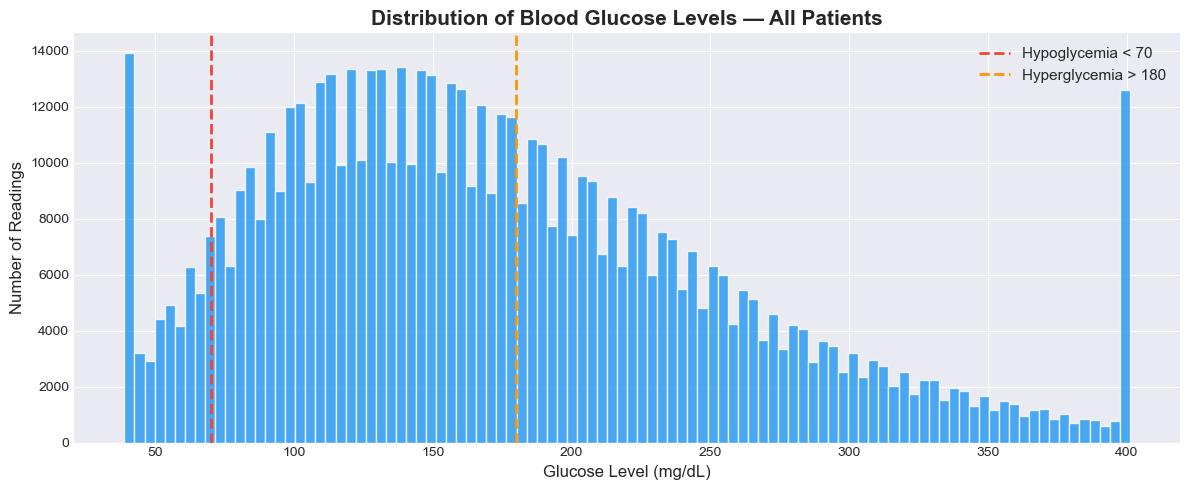

   Mean   : 173.9 mg/dL
   Median : 161.0 mg/dL
   Std    : 82.5 mg/dL
   Skew   : 0.705  (positive = right-skewed)


In [10]:
# =====================================================
# GLUCOSE DISTRIBUTION — HISTOGRAM
# =====================================================

plt.figure(figsize=(12, 5))
plt.hist(df['gl'], bins=100, color=COLORS['glucose'], edgecolor='white', alpha=0.8)
plt.axvline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=2, linestyle='--', label=f'Hypoglycemia < {HYPO_THRESHOLD}')
plt.axvline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=2, linestyle='--', label=f'Hyperglycemia > {HYPER_THRESHOLD}')
plt.title('Distribution of Blood Glucose Levels — All Patients', fontsize=15, fontweight='bold')
plt.xlabel('Glucose Level (mg/dL)', fontsize=12)
plt.ylabel('Number of Readings', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"   Mean   : {df['gl'].mean():.1f} mg/dL")
print(f"   Median : {df['gl'].median():.1f} mg/dL")
print(f"   Std    : {df['gl'].std():.1f} mg/dL")
print(f"   Skew   : {df['gl'].skew():.3f}  (positive = right-skewed)")

## **3.3 Glucose Zone Distribution**

Time-in-range (70–180 mg/dL) is the clinical gold standard. Nearly half of readings fall outside the safe range, with hyperglycemia dominant — motivating accurate 30-minute forecasting for proactive insulin adjustment.

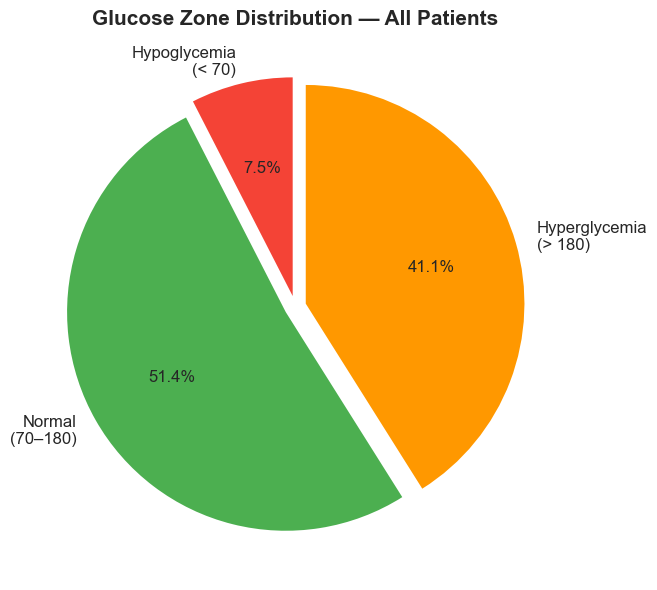

In [11]:
# =====================================================
# GLUCOSE ZONE DISTRIBUTION — PIE CHART
# =====================================================

zones       = ['Hypoglycemia\n(< 70)', 'Normal\n(70–180)', 'Hyperglycemia\n(> 180)']
zone_counts = [hypo_count, norm_count, hyper_count]
zone_colors = [COLORS['hypo'], COLORS['normal'], COLORS['hyper']]

plt.figure(figsize=(8, 6))
plt.pie(zone_counts, labels=zones, colors=zone_colors,
        autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05),
        textprops={'fontsize': 12})
plt.title('Glucose Zone Distribution — All Patients', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## **3.4 Patient Glucose Time Series**

A single patient's CGM trace shows highly **volatile and non-linear** glucose dynamics — rapid spikes and dips within short windows. This justifies sequence-based deep learning over simpler statistical approaches.

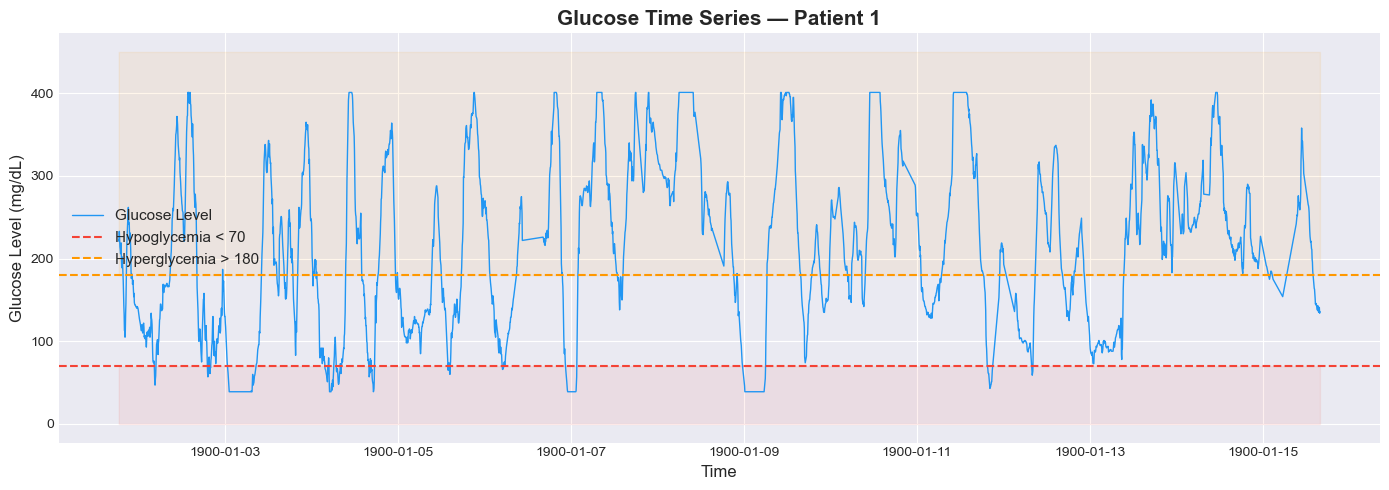

   Patient 1 — Total readings: 3,327
   Mean glucose: 213.8 mg/dL
   Std glucose:  104.6 mg/dL


In [12]:
# =====================================================
# PATIENT TIME SERIES — PATIENT 1
# =====================================================

patient = df[df['id'] == 1].copy()

plt.figure(figsize=(14, 5))
plt.plot(patient['time'], patient['gl'], color=COLORS['glucose'], linewidth=1, label='Glucose Level')
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5, linestyle='--', label=f'Hypoglycemia < {HYPO_THRESHOLD}')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5, linestyle='--', label=f'Hyperglycemia > {HYPER_THRESHOLD}')
plt.fill_between(patient['time'], 0, HYPO_THRESHOLD, alpha=0.08, color=COLORS['hypo'])
plt.fill_between(patient['time'], HYPER_THRESHOLD, 450, alpha=0.08, color=COLORS['hyper'])
plt.title('Glucose Time Series — Patient 1', fontsize=15, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Glucose Level (mg/dL)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"   Patient 1 — Total readings: {len(patient):,}")
print(f"   Mean glucose: {patient['gl'].mean():.1f} mg/dL")
print(f"   Std glucose:  {patient['gl'].std():.1f} mg/dL")

## **3.5 Per-Patient Statistics & Variability**

Readings per patient range from a few hundred to over 5,000, and mean glucose levels vary substantially. This **inter-patient variability** is a key challenge for a global forecasting model.

 Per-Patient Glucose Statistics (Top 10 by Mean Glucose):
 id  Total_Readings  Mean_Glucose  Std_Glucose  Min_Glucose  Max_Glucose
175            1838         265.4        111.5         44.0        401.0
171            2916         264.8         93.4         39.0        401.0
147            1869         248.2         99.4         39.0        401.0
166            2110         246.2         96.6         39.0        401.0
153            3007         243.7         96.9         65.0        401.0
 94            3713         242.2         71.6         82.0        401.0
 79             457         239.4         76.6        105.0        401.0
203            2316         237.3        119.3         39.0        401.0
184            1250         237.1         71.4         58.0        401.0
 93            3739         236.0         96.3         39.0        401.0

   Average readings per patient : 3239
   Most readings in one patient : 5146
   Fewest readings              : 432


<Figure size 1400x500 with 0 Axes>

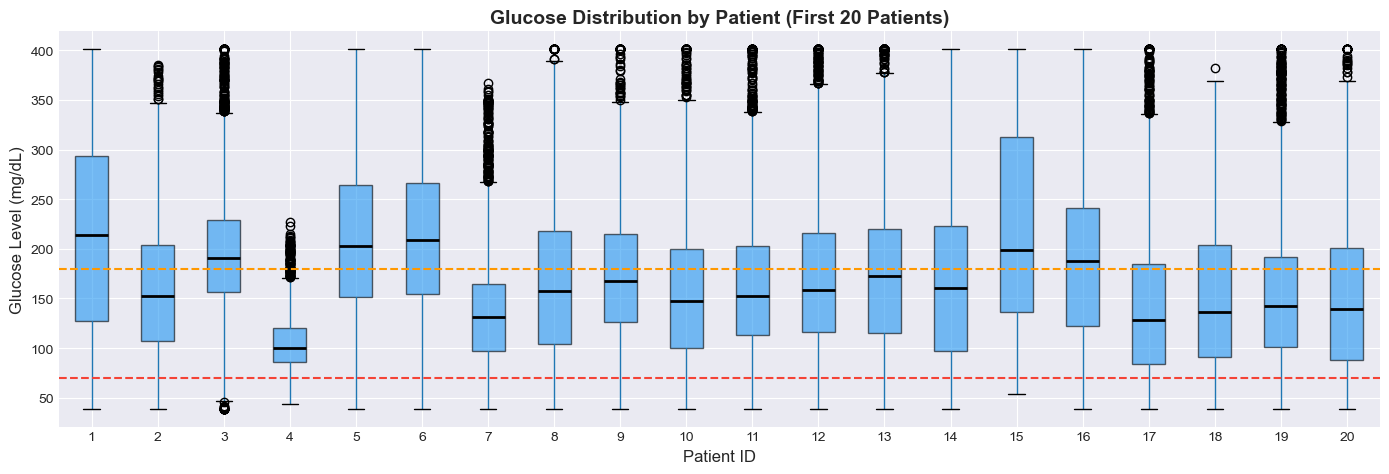

In [14]:
# =====================================================
# PER-PATIENT STATISTICS
# =====================================================

patient_stats = df.groupby('id')['gl'].agg(
    Total_Readings='count', Mean_Glucose='mean', Std_Glucose='std',
    Min_Glucose='min', Max_Glucose='max'
).round(1).reset_index()

print(" Per-Patient Glucose Statistics (Top 10 by Mean Glucose):")
print(patient_stats.sort_values('Mean_Glucose', ascending=False).head(10).to_string(index=False))

print(f"\n   Average readings per patient : {patient_stats['Total_Readings'].mean():.0f}")
print(f"   Most readings in one patient : {patient_stats['Total_Readings'].max()}")
print(f"   Fewest readings              : {patient_stats['Total_Readings'].min()}")

# --- Boxplot: Glucose distribution across patients (sample of 20) ---
sample_ids = sorted(df['id'].unique()[:20])
sample_df  = df[df['id'].isin(sample_ids)]

plt.figure(figsize=(14, 5))
sample_df.boxplot(column='gl', by='id', figsize=(14, 5),
                  patch_artist=True,
                  boxprops=dict(facecolor=COLORS['glucose'], alpha=0.6),
                  medianprops=dict(color='black', linewidth=2))
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5, linestyle='--')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5, linestyle='--')
plt.title('Glucose Distribution by Patient (First 20 Patients)', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove auto-title from pandas boxplot
plt.xlabel('Patient ID', fontsize=12)
plt.ylabel('Glucose Level (mg/dL)', fontsize=12)
plt.tight_layout()
plt.show()

## **3.6 Time Gap Analysis**

CGM devices record every 5 minutes, but gaps occur due to sensor removal or malfunction. Gaps exceeding our threshold will **break sequences** during data preparation to avoid feeding misleading patterns to the models.

In [15]:
# =====================================================
# TIME GAP ANALYSIS
# =====================================================

df['time_diff'] = df.groupby('id')['time'].diff().dt.total_seconds() / 60  # minutes

exact_5    = (df['time_diff'] == 5).sum()
within_6   = (df['time_diff'] <= 6).sum()
large_gaps = (df['time_diff'] > 30).sum()
gap_breaks = (df['time_diff'] > MAX_GAP_MINUTES).sum()
valid_gaps = df['time_diff'].notna().sum()

print("📊 Time Gap Between Readings (minutes):")
print(df['time_diff'].describe().round(2))
print(f"\n✅ Exact 5-min gaps   : {exact_5:,}   ({exact_5/valid_gaps*100:.1f}%)")
print(f"✅ Within 6-min gaps  : {within_6:,}  ({within_6/valid_gaps*100:.1f}%)")
print(f"⚠️  Gaps > 30 minutes  : {large_gaps:,}   ({large_gaps/valid_gaps*100:.1f}%)")
print(f"⚠️  Gaps > {MAX_GAP_MINUTES} min (will break sequences): {gap_breaks:,}")

## **3.7 Glucose by Hour of Day**

This plot reveals a clear **diurnal (daily) pattern** — glucose tends to be lower during early-morning sleep hours (4–6 AM) and rises during daytime hours corresponding to meals and activity. The wide standard deviation band at every hour confirms high between-patient variability, reinforcing the difficulty of a one-size-fits-all model.

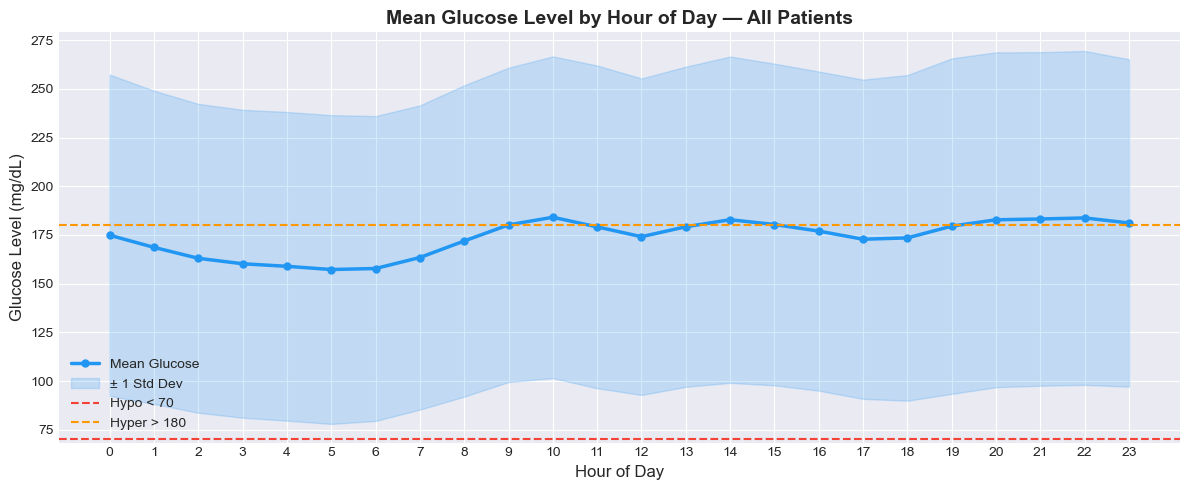

In [17]:
# =====================================================
# GLUCOSE BY HOUR OF DAY
# =====================================================

df['hour'] = df['time'].dt.hour
hourly_stats = df.groupby('hour')['gl'].agg(['mean', 'std']).reset_index()
hourly_stats.columns = ['hour', 'mean_gl', 'std_gl']

plt.figure(figsize=(12, 5))
plt.plot(hourly_stats['hour'], hourly_stats['mean_gl'],
         color=COLORS['glucose'], linewidth=2.5, marker='o', markersize=5, label='Mean Glucose')
plt.fill_between(hourly_stats['hour'],
                 hourly_stats['mean_gl'] - hourly_stats['std_gl'],
                 hourly_stats['mean_gl'] + hourly_stats['std_gl'],
                 alpha=0.2, color=COLORS['glucose'], label='± 1 Std Dev')
plt.axhline(HYPO_THRESHOLD,  color=COLORS['hypo'],  linewidth=1.5, linestyle='--', label=f'Hypo < {HYPO_THRESHOLD}')
plt.axhline(HYPER_THRESHOLD, color=COLORS['hyper'], linewidth=1.5, linestyle='--', label=f'Hyper > {HYPER_THRESHOLD}')
plt.title('Mean Glucose Level by Hour of Day — All Patients', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Glucose Level (mg/dL)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## **3.8 Autocorrelation Analysis**

Autocorrelation measures how strongly a glucose reading correlates with its own past values. High autocorrelation at short lags confirms that recent glucose values are highly predictive of the next value — the foundational assumption behind our sliding-window forecasting approach. The Partial Autocorrelation Function (PACF) isolates the direct contribution of each lag after removing intermediate effects.

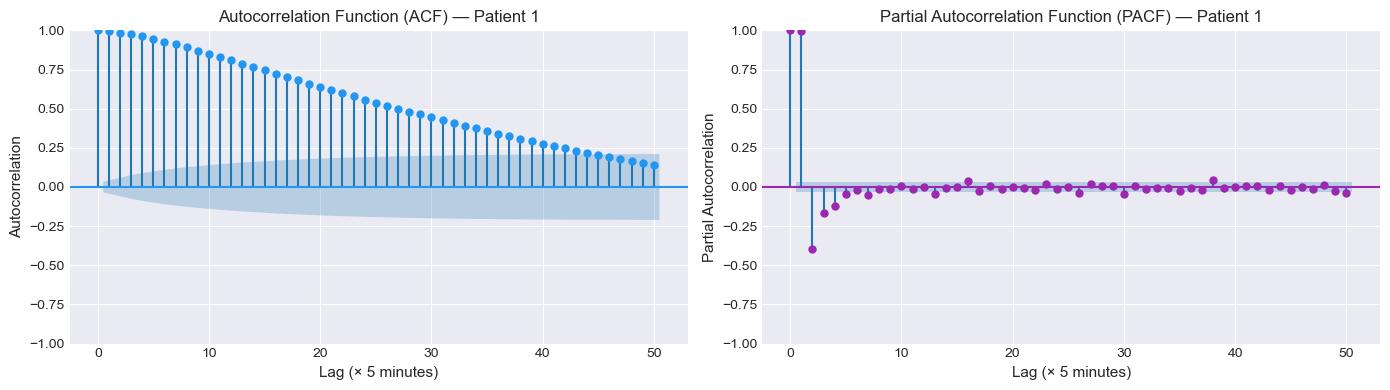

Interpretation:
  • High ACF at short lags confirms strong temporal dependence — recent
    glucose values are highly predictive of the next reading.
  • PACF drops off after ~2-3 lags, suggesting the direct predictive
    signal is concentrated in the most recent 10-15 minutes.
  • This supports our choice of a 12-step (1-hour) input window.


In [18]:
# =====================================================
# AUTOCORRELATION & PARTIAL AUTOCORRELATION
# =====================================================

patient_acf = df[df['id'] == 1]['gl'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF
plot_acf(patient_acf, lags=50, ax=axes[0], color=COLORS['glucose'],
         title='Autocorrelation Function (ACF) — Patient 1')
axes[0].set_xlabel('Lag (× 5 minutes)', fontsize=11)
axes[0].set_ylabel('Autocorrelation', fontsize=11)

# PACF
plot_pacf(patient_acf, lags=50, ax=axes[1], color=COLORS['lstm'],
          title='Partial Autocorrelation Function (PACF) — Patient 1', method='ywm')
axes[1].set_xlabel('Lag (× 5 minutes)', fontsize=11)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=11)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  • High ACF at short lags confirms strong temporal dependence — recent")
print("    glucose values are highly predictive of the next reading.")
print("  • PACF drops off after ~2-3 lags, suggesting the direct predictive")
print("    signal is concentrated in the most recent 10-15 minutes.")
print("  • This supports our choice of a 12-step (1-hour) input window.")

## **3.9 Stationarity Test (Augmented Dickey-Fuller)**

The ADF test checks whether the glucose series is stationary (constant mean/variance over time). A stationary series is easier for models to learn. Non-stationarity is addressed by our differencing features (gl_diff).

In [19]:
# =====================================================
# AUGMENTED DICKEY-FULLER TEST
# =====================================================

# Test on Patient 1
patient_gl = df[df['id'] == 1]['gl'].dropna().values

adf_result = adfuller(patient_gl, maxlag=50)

print("📊 Augmented Dickey-Fuller Test — Patient 1:")
print(f"   Test Statistic : {adf_result[0]:.4f}")
print(f"   p-value        : {adf_result[1]:.6f}")
print(f"   Lags Used      : {adf_result[2]}")
print(f"   Observations   : {adf_result[3]}")
print(f"\n   Critical Values:")
for key, val in adf_result[4].items():
    print(f"      {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print(f"\n✅ p-value ({adf_result[1]:.6f}) < 0.05 → Series is STATIONARY.")
    print("   The glucose series does not have a unit root.")
else:
    print(f"\n⚠️  p-value ({adf_result[1]:.6f}) >= 0.05 → Series is NON-STATIONARY.")
    print("   Differencing features (gl_diff) will help the models handle this.")

📊 Augmented Dickey-Fuller Test — Patient 1:
   Test Statistic : -6.2672
   p-value        : 0.000000
   Lags Used      : 6
   Observations   : 3320

   Critical Values:
      1%: -3.4323
      5%: -2.8624
      10%: -2.5672

✅ p-value (0.000000) < 0.05 → Series is STATIONARY.
   The glucose series does not have a unit root.


## **3.10 Feature Correlation with Glucose**

This analysis identifies which clinical and demographic features correlate with glucose. Most static features show weak correlation (expected — glucose is driven by temporal dynamics), confirming the CGM time-series signal is the dominant predictor.

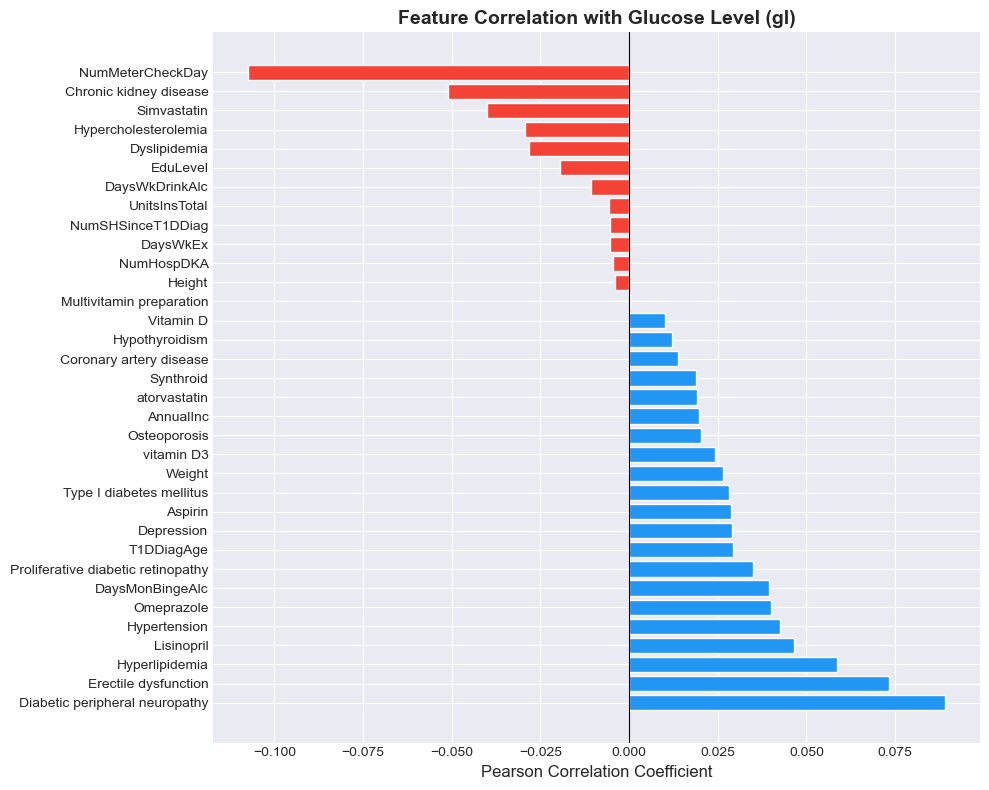


🔝 Top 5 Positively Correlated:
Diabetic peripheral neuropathy    0.0891
Erectile dysfunction              0.0732
Hyperlipidemia                    0.0585
Lisinopril                        0.0464
Hypertension                      0.0426

🔻 Top 5 Negatively Correlated:
Dyslipidemia             -0.0281
Hypercholesterolemia     -0.0294
Simvastatin              -0.0401
Chronic kidney disease   -0.0511
NumMeterCheckDay         -0.1074


In [20]:
# =====================================================
# FEATURE CORRELATION WITH GLUCOSE
# =====================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['id', 'time_diff', 'hour']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df[numeric_cols].corr()
gl_corr = corr_matrix['gl'].drop('gl').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = [COLORS['hypo'] if v < 0 else COLORS['glucose'] for v in gl_corr.values]
plt.barh(gl_corr.index, gl_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Glucose Level (gl)', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.tight_layout()
plt.show()

print("\n🔝 Top 5 Positively Correlated:")
print(gl_corr.head(5).round(4).to_string())
print("\n🔻 Top 5 Negatively Correlated:")
print(gl_corr.tail(5).round(4).to_string())

# **4. Data Preprocessing**

## **4.1 Outlier Handling — Glucose Clipping**

The CGM sensor caps at 401 mg/dL — an instrument artefact. Clipping to the clinically valid 40–400 mg/dL range removes this artificial ceiling.

In [21]:
# =====================================================
# CLIP GLUCOSE TO CLINICAL RANGE
# =====================================================

print("📊 Before Clipping:")
print(f"   Min glucose : {df['gl'].min():.1f} mg/dL")
print(f"   Max glucose : {df['gl'].max():.1f} mg/dL")
print(f"   Readings at 401 (sensor cap) : {(df['gl'] == 401).sum():,}")

df['gl'] = df['gl'].clip(lower=GL_MIN, upper=GL_MAX)

print("\n📊 After Clipping:")
print(f"   Min glucose : {df['gl'].min():.1f} mg/dL")
print(f"   Max glucose : {df['gl'].max():.1f} mg/dL")
print("\n✅ Outlier clipping complete — glucose range now [40, 400] mg/dL")

📊 Before Clipping:
   Min glucose : 39.0 mg/dL
   Max glucose : 401.0 mg/dL
   Readings at 401 (sensor cap) : 11,978

📊 After Clipping:
   Min glucose : 40.0 mg/dL
   Max glucose : 400.0 mg/dL

✅ Outlier clipping complete — glucose range now [40, 400] mg/dL


## **4.2 Feature Engineering**

Before creating sequences, we engineer additional features that give the models richer temporal context. These include:

- **Lag features** — recent glucose values (5, 10, 15 mins ago), providing short-term memory
- **Difference features** — rate of change, telling the model whether glucose is rising/falling
- **Rolling statistics** — smoothed trend (mean) and variability (std) at multiple horizons
- **Hour of day** — captures the diurnal pattern identified in EDA

All features are engineered **per patient** to prevent information leakage across patients.

In [22]:
# =====================================================
# FEATURE ENGINEERING — PER PATIENT
# =====================================================

# --- Lag Features (recent glucose history) ---
df['gl_lag1'] = df.groupby('id')['gl'].shift(1)   # 5 mins ago
df['gl_lag2'] = df.groupby('id')['gl'].shift(2)   # 10 mins ago
df['gl_lag3'] = df.groupby('id')['gl'].shift(3)   # 15 mins ago

# --- Difference Features (rate of change) ---
df['gl_diff1'] = df.groupby('id')['gl'].diff(1)   # change over 5 mins
df['gl_diff2'] = df.groupby('id')['gl'].diff(2)   # change over 10 mins

# --- Rolling Statistics ---
df['rolling_mean_6']  = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=6, min_periods=1).mean())    # 30-min mean
df['rolling_mean_12'] = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=12, min_periods=1).mean())   # 1-hour mean
df['rolling_mean_36'] = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=36, min_periods=1).mean())   # 3-hour mean
df['rolling_std_6']   = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=6, min_periods=1).std().fillna(0))   # 30-min std
df['rolling_std_12']  = df.groupby('id')['gl'].transform(
    lambda x: x.rolling(window=12, min_periods=1).std().fillna(0))  # 1-hour std

# --- Hour of Day (already created in EDA) ---
# df['hour'] already exists

# --- Drop rows with NaN from lag/diff operations ---
initial_len = len(df)
df = df.dropna(subset=['gl_lag1', 'gl_lag2', 'gl_lag3', 'gl_diff1', 'gl_diff2']).reset_index(drop=True)

print("✅ Feature engineering complete!")
print(f"   Rows before: {initial_len:,}")
print(f"   Rows after dropping NaN from lags: {len(df):,}")
print(f"   Rows removed: {initial_len - len(df):,}")
print(f"\n📋 New features: gl_lag1, gl_lag2, gl_lag3, gl_diff1, gl_diff2,")
print(f"   rolling_mean_6, rolling_mean_12, rolling_mean_36, rolling_std_6, rolling_std_12, hour")
print(f"\n📋 Sample:")
df[['id', 'time', 'gl', 'gl_lag1', 'gl_diff1', 'rolling_mean_12', 'hour']].head(8)

✅ Feature engineering complete!
   Rows before: 647,858
   Rows after dropping NaN from lags: 647,258
   Rows removed: 600

📋 New features: gl_lag1, gl_lag2, gl_lag3, gl_diff1, gl_diff2,
   rolling_mean_6, rolling_mean_12, rolling_mean_36, rolling_std_6, rolling_std_12, hour

📋 Sample:


,id,time,gl,gl_lag1,gl_diff1,rolling_mean_12,hour
0,1,1900-01-01 18:50:14,223.0,233.0,-10.0,225.000000,18
1,1,1900-01-01 18:55:14,214.0,223.0,-9.0,222.800000,18
2,1,1900-01-01 19:00:14,211.0,214.0,-3.0,220.833333,19
3,1,1900-01-01 19:05:14,206.0,211.0,-5.0,218.714286,19
4,1,1900-01-01 19:10:14,208.0,206.0,2.0,217.375000,19
5,1,1900-01-01 19:15:13,219.0,208.0,11.0,217.555556,19
6,1,1900-01-01 19:20:13,198.0,219.0,-21.0,215.600000,19
7,1,1900-01-01 19:25:13,189.0,198.0,-9.0,213.181818,19


## **4.3 Normalisation**

All features are scaled to [0, 1] using MinMaxScaler. This is critical for deep learning — unnormalised values cause unstable gradients and slow convergence.

**Important:** We define our feature columns and target column separately. The glucose column (`gl`) is normalised by its own dedicated scaler so we can accurately inverse-transform predictions back to mg/dL for clinical evaluation. All other features share a separate scaler.

In [23]:
# =====================================================
# NORMALISATION
# =====================================================

# --- Define feature columns (inputs to the model) ---
feature_cols = [
    'gl',                # raw glucose (will be scaled)
    'gl_lag1', 'gl_lag2', 'gl_lag3',
    'gl_diff1', 'gl_diff2',
    'rolling_mean_6', 'rolling_mean_12', 'rolling_mean_36',
    'rolling_std_6', 'rolling_std_12',
    'hour',
]

# --- Glucose scaler (separate — needed for inverse transform) ---
gl_scaler = MinMaxScaler(feature_range=(0, 1))
df['gl_scaled'] = gl_scaler.fit_transform(df[['gl']])

print("✅ Glucose scaler fitted:")
print(f"   Min (maps to 0): {gl_scaler.data_min_[0]:.1f} mg/dL")
print(f"   Max (maps to 1): {gl_scaler.data_max_[0]:.1f} mg/dL")

# --- Feature scaler (all input features) ---
feature_scaler = MinMaxScaler(feature_range=(0, 1))
df[feature_cols] = feature_scaler.fit_transform(df[feature_cols])

print(f"\n✅ All {len(feature_cols)} features normalised to [0, 1]!")
print(f"   Feature columns: {feature_cols}")
print(f"\n📋 Sample (scaled):")
df[['id', 'gl_scaled'] + feature_cols[:4]].head(5)

✅ Glucose scaler fitted:
   Min (maps to 0): 40.0 mg/dL
   Max (maps to 1): 400.0 mg/dL

✅ All 12 features normalised to [0, 1]!
   Feature columns: ['gl', 'gl_lag1', 'gl_lag2', 'gl_lag3', 'gl_diff1', 'gl_diff2', 'rolling_mean_6', 'rolling_mean_12', 'rolling_mean_36', 'rolling_std_6', 'rolling_std_12', 'hour']

📋 Sample (scaled):


,id,gl_scaled,gl,gl_lag1,gl_lag2,gl_lag3
0,1,0.508333,0.508333,0.536111,0.502778,0.508333
1,1,0.483333,0.483333,0.508333,0.536111,0.502778
2,1,0.475000,0.475000,0.483333,0.508333,0.536111
3,1,0.461111,0.461111,0.475000,0.483333,0.508333
4,1,0.466667,0.466667,0.461111,0.475000,0.483333


## **4.4 Sequence Creation (with Time-Gap Handling)**

The sliding-window approach converts the time series into structured input-output pairs:
- **Input:** 12 timesteps (1 hour of history) × 12 features per step
- **Target:** Next 6 glucose values (30 minutes ahead), using the separately-scaled `gl_scaled`

**Critical improvement:** Sequences are **broken at large time gaps** (> 15 minutes). Without this, a sequence could span a period where the sensor was removed, feeding the model a false pattern of sudden glucose change that is actually just a data gap.

In [24]:
# =====================================================
# SEQUENCE CREATION — WITH GAP HANDLING
# =====================================================

def create_sequences_with_gap_check(patient_data, feature_cols, seq_len, horizon, max_gap):
    """
    Create input-output sequence pairs, breaking at time gaps > max_gap minutes.
    
    Input X: (seq_len, n_features) — multivariate features
    Target y: (horizon,) — future glucose values (gl_scaled)
    """
    X, y = [], []
    features = patient_data[feature_cols].values
    target   = patient_data['gl_scaled'].values
    gaps     = patient_data['time_diff'].values
    
    total_window = seq_len + horizon
    
    for i in range(len(features) - total_window + 1):
        # Check if any gap in this window exceeds the threshold
        window_gaps = gaps[i+1 : i + total_window]  # i+1 because first row has no gap
        if np.nanmax(window_gaps) > max_gap:
            continue  # Skip this window — it spans a data gap
        
        X.append(features[i : i + seq_len])
        y.append(target[i + seq_len : i + seq_len + horizon])
    
    return np.array(X) if X else np.empty((0, seq_len, len(feature_cols))), \
           np.array(y) if y else np.empty((0, horizon))

# --- Build sequences for all patients ---
all_X, all_y = [], []
skipped_patients = 0

for pid in df['id'].unique():
    pdata = df[df['id'] == pid].copy()
    X, y = create_sequences_with_gap_check(
        pdata, feature_cols, SEQUENCE_LENGTH, FORECAST_HORIZON, MAX_GAP_MINUTES)
    if len(X) > 0:
        all_X.append(X)
        all_y.append(y)
    else:
        skipped_patients += 1

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

print("✅ Sequence creation complete (with gap handling)!")
print(f"\n   Input shape  (X) : {X_all.shape}  → (samples, {SEQUENCE_LENGTH} steps, {len(feature_cols)} features)")
print(f"   Target shape (y) : {y_all.shape}  → (samples, {FORECAST_HORIZON} steps ahead)")
print(f"\n   Total valid sequences : {X_all.shape[0]:,}")
print(f"   Patients skipped (too few valid sequences): {skipped_patients}")
print(f"\n   Each sample: {SEQUENCE_LENGTH} steps ({SEQUENCE_LENGTH*5} mins) → predicts {FORECAST_HORIZON} steps ({FORECAST_HORIZON*5} mins)")

✅ Sequence creation complete (with gap handling)!

   Input shape  (X) : (581512, 12, 12)  → (samples, 12 steps, 12 features)
   Target shape (y) : (581512, 6)  → (samples, 6 steps ahead)

   Total valid sequences : 581,512
   Patients skipped (too few valid sequences): 0

   Each sample: 12 steps (60 mins) → predicts 6 steps (30 mins)


## **4.5 Train / Validation / Test Split**

A **time-based 70/15/15 split** preserves temporal ordering — the model trains only on past data and is evaluated on truly unseen future sequences. Random splitting would leak future information into training, producing inflated metrics that would not hold in clinical practice.

In [25]:
# =====================================================
# TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# =====================================================

total     = len(X_all)
train_end = int(total * TRAIN_RATIO)
val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

print("✅ Time-based split complete!")
print(f"\n   Total sequences : {total:,}")
print(f"   X_train : {X_train.shape}  — {len(X_train):,} samples ({TRAIN_RATIO*100:.0f}%)")
print(f"   X_val   : {X_val.shape}  — {len(X_val):,} samples ({VAL_RATIO*100:.0f}%)")
print(f"   X_test  : {X_test.shape}  — {len(X_test):,} samples ({TEST_RATIO*100:.0f}%)")
print(f"\n   y_train : {y_train.shape}")
print(f"   y_val   : {y_val.shape}")
print(f"   y_test  : {y_test.shape}")

# --- Input shape for all models ---
input_shape = (X_train.shape[1], X_train.shape[2])
print(f"\n   Model input shape: {input_shape}")

# --- Memory usage ---
total_mb = (X_train.nbytes + X_val.nbytes + X_test.nbytes +
            y_train.nbytes + y_val.nbytes + y_test.nbytes) / 1024**2
print(f"   Total memory: {total_mb:.1f} MB")

✅ Time-based split complete!

   Total sequences : 581,512
   X_train : (407058, 12, 12)  — 407,058 samples (70%)
   X_val   : (87227, 12, 12)  — 87,227 samples (15%)
   X_test  : (87227, 12, 12)  — 87,227 samples (15%)

   y_train : (407058, 6)
   y_val   : (87227, 6)
   y_test  : (87227, 6)

   Model input shape: (12, 12)
   Total memory: 665.5 MB


# **5. Model Development**

Three deep learning architectures are trained and compared. All models share identical training configuration (optimizer, learning rate, callbacks, batch size) to ensure a fair comparison. Each model receives the same multivariate input sequences and predicts the same 6-step glucose forecast.

| Component | LSTM | GRU | CNN |
|---|---|---|---|
| Layer 1 | LSTM(64) | GRU(64) | Conv1D(64, kernel=3) |
| Layer 2 | LSTM(32) | GRU(32) | MaxPooling1D + Conv1D(32) |
| Regularisation | Dropout(0.2) | Dropout(0.2) | Dropout(0.2) |
| Output | Dense(6) | Dense(6) | Flatten → Dense(6) |
| Optimizer | Adam (lr=0.001) | Adam (lr=0.001) | Adam (lr=0.001) |
| Loss | MSE | MSE | MSE |

## **5.1 LSTM (Long Short-Term Memory)**

LSTM networks are specifically designed for sequential data. The memory cell and gating mechanisms (forget, input, output gates) allow the model to learn both short-term and long-term temporal dependencies in glucose patterns. Two stacked LSTM layers with dropout regularisation are used to prevent overfitting.

In [26]:
# =====================================================
# LSTM MODEL — BUILD & TRAIN
# =====================================================

def build_lstm(input_shape, forecast_horizon):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_lstm.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

lstm_model = build_lstm(input_shape, FORECAST_HORIZON)
lstm_model.summary()

print("\n🚀 Training LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm, verbose=1
)
print("\n✅ LSTM training complete!")

2026-04-13 08:54:33.892337: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-13 08:54:33.892737: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-13 08:54:33.892746: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1776052473.893212 11118047 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1776052473.893468 11118047 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,382 (130.40 KB)

 Trainable params: 33,382 (130.40 KB)

...


🚀 Training LSTM...
Epoch 1/100


2026-04-13 08:54:35.384992: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1776052475.389468 11118047 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


6361/6361 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0081 - mae: 0.0569

E0000 00:00:1776052563.876978 11118047 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


6361/6361 ━━━━━━━━━━━━━━━━━━━━ 95s 15ms/step - loss: 0.0081 - mae: 0.0569 - val_loss: 0.0030 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 2/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 98s 15ms/step - loss: 0.0027 - mae: 0.0350 - val_loss: 0.0037 - val_mae: 0.0450 - learning_rate: 0.0010
Epoch 3/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 93s 15ms/step - loss: 0.0025 - mae: 0.0334 - val_loss: 0.0044 - val_mae: 0.0498 - learning_rate: 0.0010
Epoch 4/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 84s 13ms/step - loss: 0.0025 - mae: 0.0328 - val_loss: 0.0043 - val_mae: 0.0493 - learning_rate: 0.0010
Epoch 5/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 92s 14ms/step - loss: 0.0024 - mae: 0.0324 - val_loss: 0.0045 - val_mae: 0.0499 - learning_rate: 0.0010
Epoch 6/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024 - mae: 0.0321
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 93s 15ms/step - loss: 0.0024 - mae: 0.0321 - val_loss: 0.0042 - val_mae: 0.0487 - lea

## **5.2 LSTM Evaluation**

The loss curve verifies convergence — validation loss should decrease and stabilise without diverging from training loss (which would indicate overfitting). Predictions are inverse-transformed back to mg/dL using the glucose-specific scaler for clinically meaningful evaluation.

E0000 00:00:1776053493.198398 11118047 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


📊 LSTM Results:
   MAE  : 13.96 mg/dL
   RMSE : 19.96 mg/dL
   R²   : 0.9447


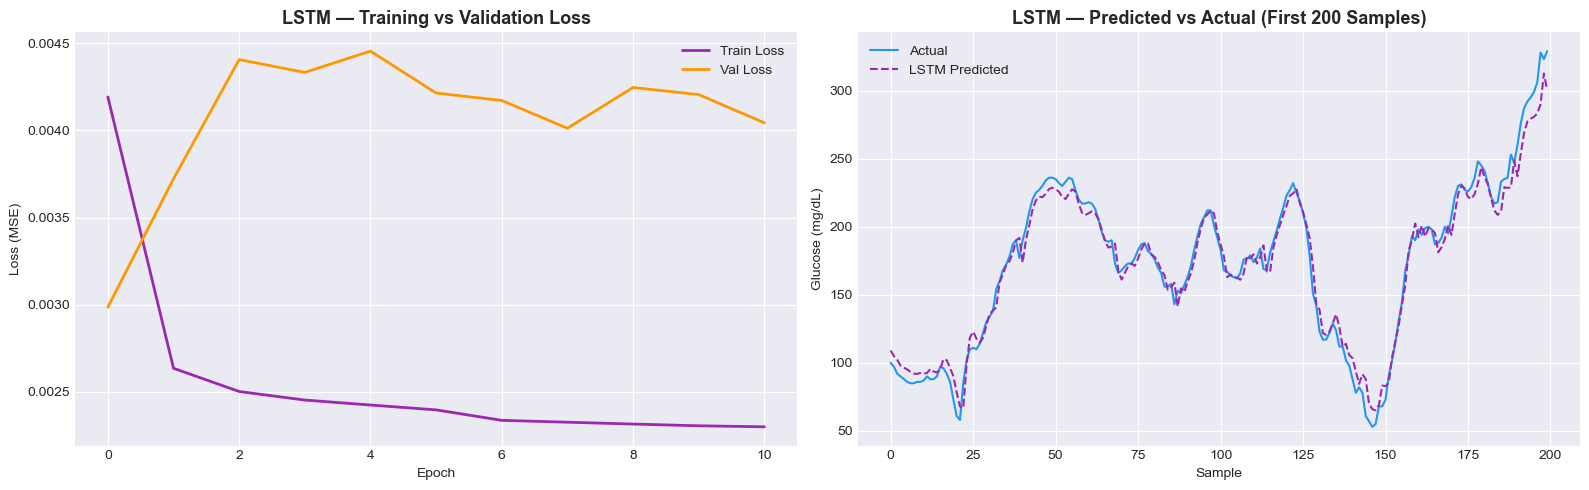

In [27]:
# =====================================================
# LSTM — EVALUATION
# =====================================================

# --- Helper: inverse transform predictions back to mg/dL ---
def inverse_gl(data, scaler):
    """Inverse-transform scaled glucose values back to mg/dL."""
    return scaler.inverse_transform(data.reshape(-1, 1)).reshape(data.shape)

# --- Predictions ---
lstm_pred = lstm_model.predict(X_test, verbose=0)

lstm_pred_inv = inverse_gl(lstm_pred, gl_scaler)
y_test_inv    = inverse_gl(y_test, gl_scaler)

# --- Metrics ---
lstm_mae  = mean_absolute_error(y_test_inv.flatten(), lstm_pred_inv.flatten())
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), lstm_pred_inv.flatten()))
lstm_r2   = r2_score(y_test_inv.flatten(), lstm_pred_inv.flatten())

print("📊 LSTM Results:")
print(f"   MAE  : {lstm_mae:.2f} mg/dL")
print(f"   RMSE : {lstm_rmse:.2f} mg/dL")
print(f"   R²   : {lstm_r2:.4f}")

# --- Plot 1: Loss Curve ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(lstm_history.history['loss'],     color=COLORS['lstm'], linewidth=2, label='Train Loss')
axes[0].plot(lstm_history.history['val_loss'], color=COLORS['hyper'], linewidth=2, label='Val Loss')
axes[0].set_title('LSTM — Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

# --- Plot 2: Predicted vs Actual ---
axes[1].plot(y_test_inv[:200, 0],    color=COLORS['glucose'], linewidth=1.5, label='Actual')
axes[1].plot(lstm_pred_inv[:200, 0], color=COLORS['lstm'],    linewidth=1.5, linestyle='--', label='LSTM Predicted')
axes[1].set_title('LSTM — Predicted vs Actual (First 200 Samples)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].legend()

plt.tight_layout()
plt.show()

## **5.3 GRU (Gated Recurrent Unit)**

GRU is a lighter alternative to LSTM that merges the forget and input gates into a single update gate, reducing the number of parameters. It often trains faster while achieving comparable performance. Using identical hyperparameters ensures a fair head-to-head comparison with LSTM.

In [28]:
# =====================================================
# GRU MODEL — BUILD & TRAIN
# =====================================================

def build_gru(input_shape, forecast_horizon):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

callbacks_gru = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_gru.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

gru_model = build_gru(input_shape, FORECAST_HORIZON)
gru_model.summary()

print("\n🚀 Training GRU...")
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_gru, verbose=1
)
print("\n✅ GRU training complete!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        14,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,638 (100.15 KB)

 Trainable params: 25,638 (100.15 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training GRU...
Epoch 1/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0087 - mae: 0.0563

E0000 00:00:1776053589.193489 11118047 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


6361/6361 ━━━━━━━━━━━━━━━━━━━━ 92s 14ms/step - loss: 0.0087 - mae: 0.0563 - val_loss: 0.0029 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 2/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 89s 14ms/step - loss: 0.0027 - mae: 0.0348 - val_loss: 0.0040 - val_mae: 0.0461 - learning_rate: 0.0010
Epoch 3/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.0025 - mae: 0.0332 - val_loss: 0.0048 - val_mae: 0.0513 - learning_rate: 0.0010
Epoch 4/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.0024 - mae: 0.0324 - val_loss: 0.0053 - val_mae: 0.0539 - learning_rate: 0.0010
Epoch 5/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.0024 - mae: 0.0321 - val_loss: 0.0059 - val_mae: 0.0569 - learning_rate: 0.0010
Epoch 6/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024 - mae: 0.0318
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.0024 - mae: 0.0318 - val_loss: 0.0066 - val_mae: 0.0611 - lea

## **5.4 GRU Evaluation**

Comparing GRU against LSTM reveals whether the simpler gating mechanism achieves comparable forecasting accuracy. If GRU matches LSTM at lower computational cost, it would be the preferred choice for real-time clinical deployment on resource-constrained CGM devices.

E0000 00:00:1776054485.847331 11118047 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


📊 GRU Results:
   MAE  : 13.80 mg/dL
   RMSE : 19.90 mg/dL
   R²   : 0.9450


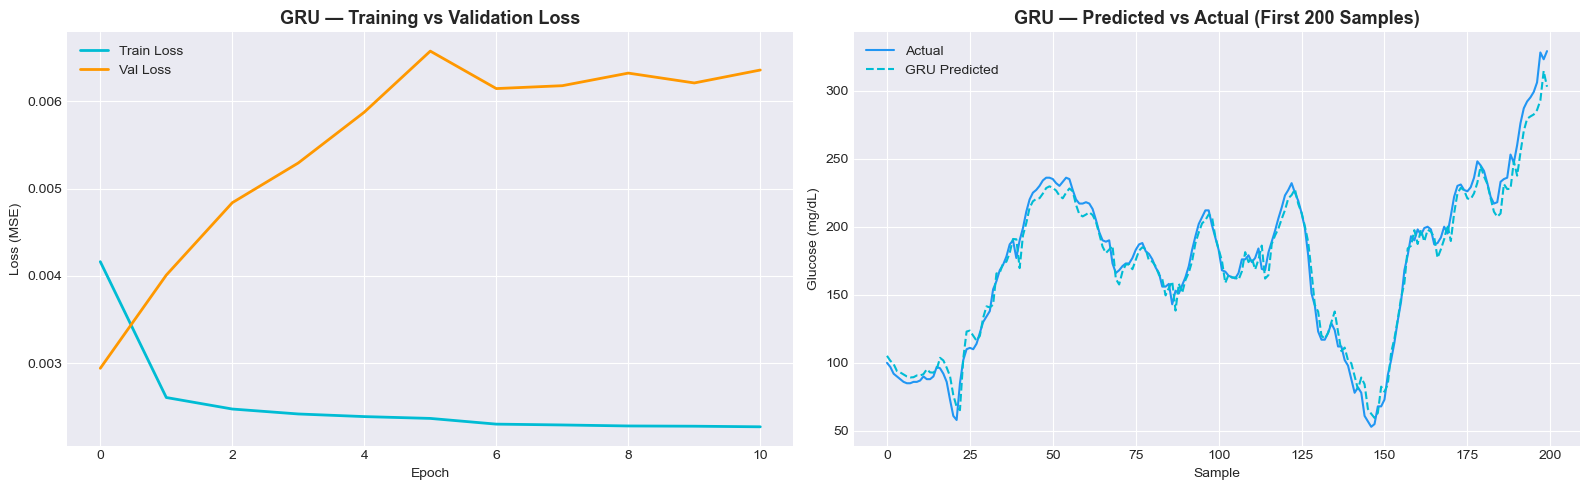

In [29]:
# =====================================================
# GRU — EVALUATION
# =====================================================

gru_pred = gru_model.predict(X_test, verbose=0)
gru_pred_inv = inverse_gl(gru_pred, gl_scaler)

gru_mae  = mean_absolute_error(y_test_inv.flatten(), gru_pred_inv.flatten())
gru_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), gru_pred_inv.flatten()))
gru_r2   = r2_score(y_test_inv.flatten(), gru_pred_inv.flatten())

print("📊 GRU Results:")
print(f"   MAE  : {gru_mae:.2f} mg/dL")
print(f"   RMSE : {gru_rmse:.2f} mg/dL")
print(f"   R²   : {gru_r2:.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(gru_history.history['loss'],     color=COLORS['gru'], linewidth=2, label='Train Loss')
axes[0].plot(gru_history.history['val_loss'], color=COLORS['hyper'], linewidth=2, label='Val Loss')
axes[0].set_title('GRU — Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

axes[1].plot(y_test_inv[:200, 0],   color=COLORS['glucose'], linewidth=1.5, label='Actual')
axes[1].plot(gru_pred_inv[:200, 0], color=COLORS['gru'],     linewidth=1.5, linestyle='--', label='GRU Predicted')
axes[1].set_title('GRU — Predicted vs Actual (First 200 Samples)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].legend()

plt.tight_layout()
plt.show()

## **5.5 CNN (1D Convolutional Neural Network)**

Unlike LSTM and GRU, which process sequences step-by-step, CNN applies convolutional filters across the time dimension to detect local temporal patterns (e.g., rapid glucose spikes). It processes the entire input window in parallel, making it significantly faster to train. Two Conv1D layers extract features at different temporal scales.

In [30]:
# =====================================================
# CNN MODEL — BUILD & TRAIN
# =====================================================

def build_cnn(input_shape, forecast_horizon):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        Dropout(0.2),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_cnn.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

cnn_model = build_cnn(input_shape, FORECAST_HORIZON)
cnn_model.summary()

print("\n🚀 Training CNN...")
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn, verbose=1
)
print("\n✅ CNN training complete!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,894 (54.27 KB)

 Trainable params: 13,894 (54.27 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training CNN...
Epoch 1/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0070 - mae: 0.0569

E0000 00:00:1776054556.984367 11118047 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


6361/6361 ━━━━━━━━━━━━━━━━━━━━ 67s 10ms/step - loss: 0.0070 - mae: 0.0569 - val_loss: 0.0032 - val_mae: 0.0415 - learning_rate: 0.0010
Epoch 2/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - loss: 0.0034 - mae: 0.0404 - val_loss: 0.0035 - val_mae: 0.0446 - learning_rate: 0.0010
Epoch 3/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - loss: 0.0032 - mae: 0.0389 - val_loss: 0.0036 - val_mae: 0.0453 - learning_rate: 0.0010
Epoch 4/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - loss: 0.0031 - mae: 0.0381 - val_loss: 0.0038 - val_mae: 0.0468 - learning_rate: 0.0010
Epoch 5/100
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 63s 10ms/step - loss: 0.0030 - mae: 0.0376 - val_loss: 0.0041 - val_mae: 0.0500 - learning_rate: 0.0010
Epoch 6/100
6359/6361 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - mae: 0.0373
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
6361/6361 ━━━━━━━━━━━━━━━━━━━━ 65s 10ms/step - loss: 0.0030 - mae: 0.0373 - val_loss: 0.0039 - val_mae: 0.0479 - lea

## **5.6 CNN Evaluation**

The CNN evaluation completes the three-model comparison. CNN is expected to train faster but may sacrifice some accuracy on longer-range dependencies compared to recurrent models. The loss curve and prediction plot reveal whether this speed-accuracy trade-off is acceptable for 30-minute glucose forecasting.

E0000 00:00:1776055206.132389 11118047 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


📊 CNN Results:
   MAE  : 14.63 mg/dL
   RMSE : 20.33 mg/dL
   R²   : 0.9426


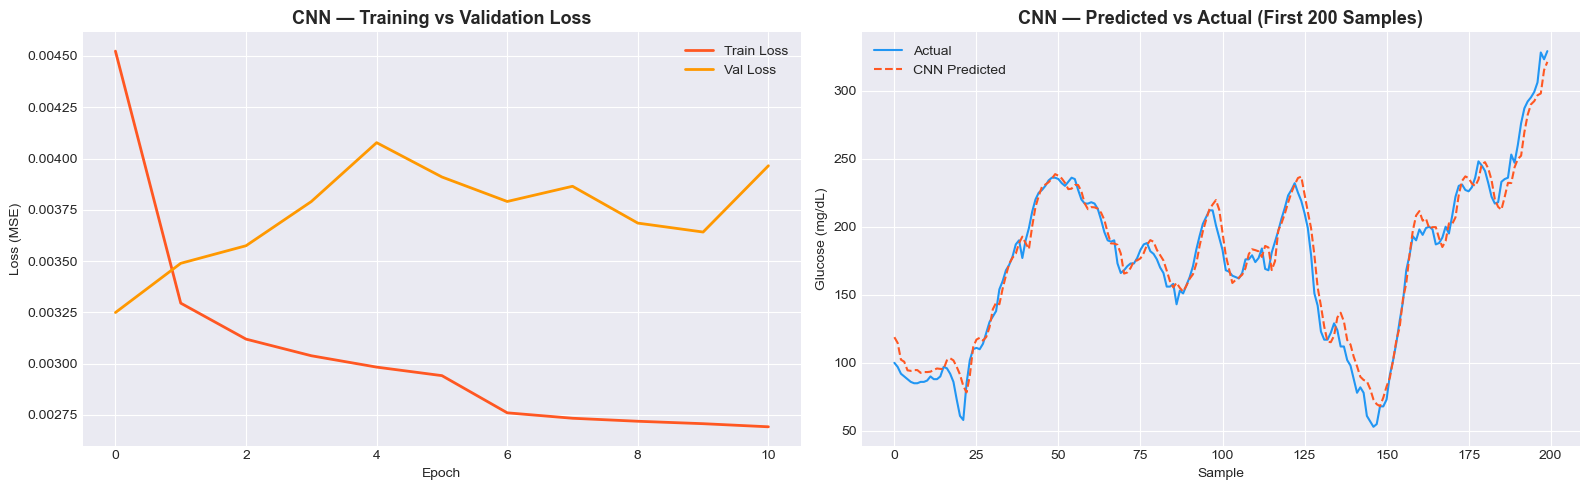

In [31]:
# =====================================================
# CNN — EVALUATION
# =====================================================

cnn_pred = cnn_model.predict(X_test, verbose=0)
cnn_pred_inv = inverse_gl(cnn_pred, gl_scaler)

cnn_mae  = mean_absolute_error(y_test_inv.flatten(), cnn_pred_inv.flatten())
cnn_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), cnn_pred_inv.flatten()))
cnn_r2   = r2_score(y_test_inv.flatten(), cnn_pred_inv.flatten())

print("📊 CNN Results:")
print(f"   MAE  : {cnn_mae:.2f} mg/dL")
print(f"   RMSE : {cnn_rmse:.2f} mg/dL")
print(f"   R²   : {cnn_r2:.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(cnn_history.history['loss'],     color=COLORS['cnn'], linewidth=2, label='Train Loss')
axes[0].plot(cnn_history.history['val_loss'], color=COLORS['hyper'], linewidth=2, label='Val Loss')
axes[0].set_title('CNN — Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

axes[1].plot(y_test_inv[:200, 0],   color=COLORS['glucose'], linewidth=1.5, label='Actual')
axes[1].plot(cnn_pred_inv[:200, 0], color=COLORS['cnn'],     linewidth=1.5, linestyle='--', label='CNN Predicted')
axes[1].set_title('CNN — Predicted vs Actual (First 200 Samples)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].legend()

plt.tight_layout()
plt.show()

# **6. Model Comparison & Results**

All three models are compared on the same unseen test set using three standard regression metrics:
- **MAE** (Mean Absolute Error) — average prediction error in mg/dL
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **R²** (Coefficient of Determination) — proportion of variance explained (1.0 = perfect)

In [32]:
# =====================================================
# FINAL MODEL COMPARISON
# =====================================================

results = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'CNN'],
    'MAE (mg/dL)':  [round(lstm_mae, 2),  round(gru_mae, 2),  round(cnn_mae, 2)],
    'RMSE (mg/dL)': [round(lstm_rmse, 2), round(gru_rmse, 2), round(cnn_rmse, 2)],
    'R²':           [round(lstm_r2, 4),   round(gru_r2, 4),   round(cnn_r2, 4)]
})

print("=" * 55)
print("        📊 FINAL MODEL COMPARISON RESULTS")
print("=" * 55)
display(results)

best_mae  = results.loc[results['MAE (mg/dL)'].idxmin(),  'Model']
best_rmse = results.loc[results['RMSE (mg/dL)'].idxmin(), 'Model']
best_r2   = results.loc[results['R²'].idxmax(),           'Model']

print(f"\n🏆 Best MAE  → {best_mae}")
print(f"🏆 Best RMSE → {best_rmse}")
print(f"🏆 Best R²   → {best_r2}")

        📊 FINAL MODEL COMPARISON RESULTS


,Model,MAE (mg/dL),RMSE (mg/dL),R²
0,LSTM,13.96,19.96,0.9447
1,GRU,13.80,19.90,0.9450
2,CNN,14.63,20.33,0.9426



🏆 Best MAE  → GRU
🏆 Best RMSE → GRU
🏆 Best R²   → GRU


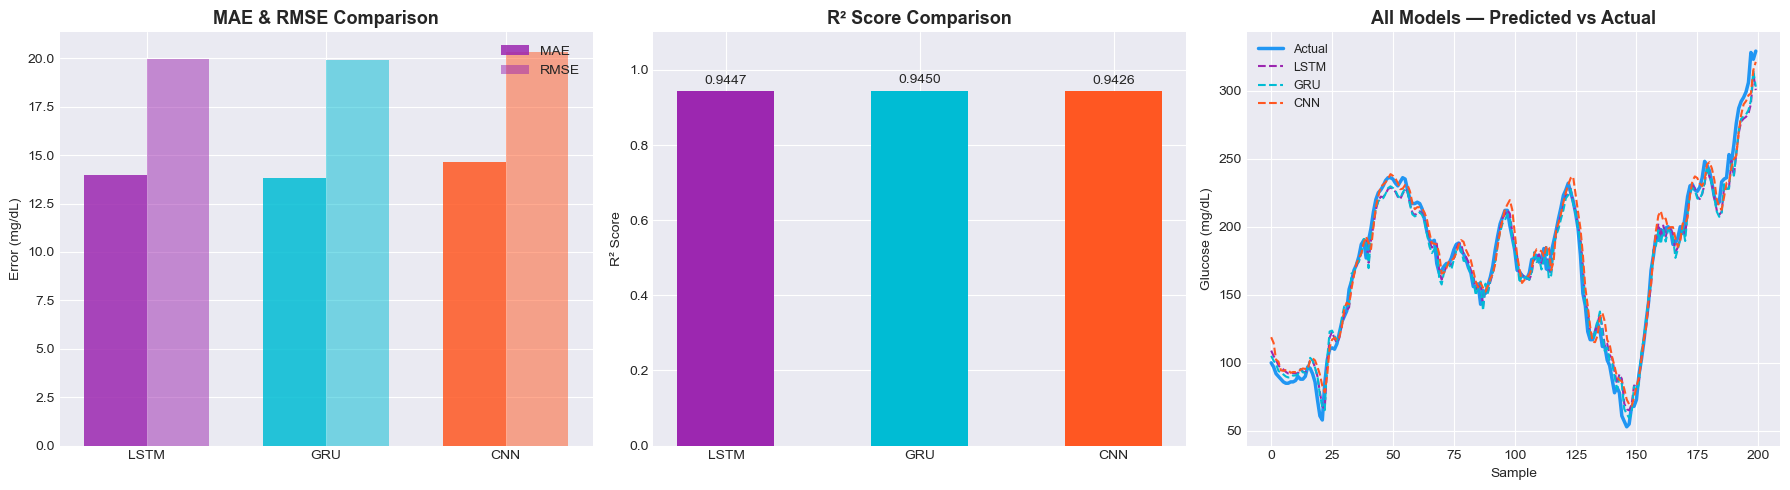

In [33]:
# =====================================================
# COMPARISON PLOTS
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = [COLORS['lstm'], COLORS['gru'], COLORS['cnn']]

# --- Plot 1: MAE & RMSE Bar Chart ---
x = np.arange(3)
w = 0.35
axes[0].bar(x - w/2, results['MAE (mg/dL)'],  w, color=model_colors, alpha=0.85, label='MAE')
axes[0].bar(x + w/2, results['RMSE (mg/dL)'], w, color=model_colors, alpha=0.50, label='RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'])
axes[0].set_ylabel('Error (mg/dL)')
axes[0].set_title('MAE & RMSE Comparison', fontsize=13, fontweight='bold')
axes[0].legend()

# --- Plot 2: R² Bar Chart ---
bars = axes[1].bar(results['Model'], results['R²'], color=model_colors, width=0.5)
axes[1].bar_label(bars, fmt='%.4f', padding=3)
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.1)

# --- Plot 3: All Models vs Actual ---
axes[2].plot(y_test_inv[:200, 0],    color=COLORS['glucose'], linewidth=2.5, label='Actual')
axes[2].plot(lstm_pred_inv[:200, 0], color=COLORS['lstm'],    linewidth=1.5, linestyle='--', label='LSTM')
axes[2].plot(gru_pred_inv[:200, 0],  color=COLORS['gru'],     linewidth=1.5, linestyle='--', label='GRU')
axes[2].plot(cnn_pred_inv[:200, 0],  color=COLORS['cnn'],     linewidth=1.5, linestyle='--', label='CNN')
axes[2].set_title('All Models — Predicted vs Actual', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('Glucose (mg/dL)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## **6.1 Per-Horizon Error Analysis**

This analysis breaks down prediction accuracy at each of the 6 forecast steps (5, 10, 15, 20, 25, 30 minutes ahead). Error naturally increases with the forecast horizon — predictions further into the future are harder. This reveals how quickly each model's accuracy degrades over time, which is clinically important for determining how far ahead the forecast remains trustworthy.

📊 MAE by Forecast Horizon (mg/dL):


,LSTM,GRU,CNN
+5 min,9.24,8.86,9.60
+10 min,10.68,10.10,11.22
+15 min,12.67,12.79,13.63
+20 min,15.20,14.90,15.35
+25 min,16.69,16.84,17.94
+30 min,19.27,19.33,20.07


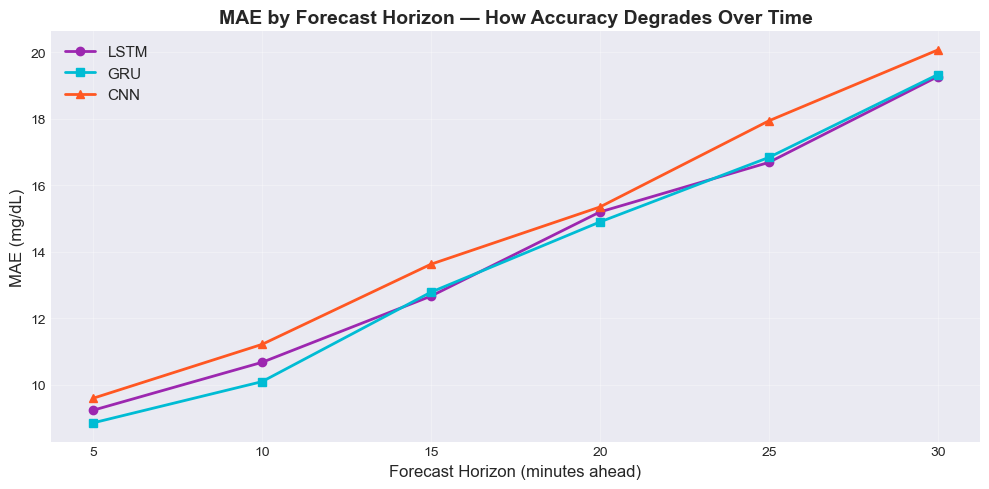

In [34]:
# =====================================================
# PER-HORIZON MAE ANALYSIS
# =====================================================

horizon_mae = pd.DataFrame()
for step in range(FORECAST_HORIZON):
    mins = (step + 1) * 5
    horizon_mae.loc[f'+{mins} min', 'LSTM'] = mean_absolute_error(
        y_test_inv[:, step], lstm_pred_inv[:, step])
    horizon_mae.loc[f'+{mins} min', 'GRU'] = mean_absolute_error(
        y_test_inv[:, step], gru_pred_inv[:, step])
    horizon_mae.loc[f'+{mins} min', 'CNN'] = mean_absolute_error(
        y_test_inv[:, step], cnn_pred_inv[:, step])

horizon_mae = horizon_mae.round(2)
print("📊 MAE by Forecast Horizon (mg/dL):")
display(horizon_mae)

# --- Plot ---
plt.figure(figsize=(10, 5))
steps = [5, 10, 15, 20, 25, 30]
plt.plot(steps, horizon_mae['LSTM'].values, color=COLORS['lstm'], marker='o', linewidth=2, label='LSTM')
plt.plot(steps, horizon_mae['GRU'].values,  color=COLORS['gru'],  marker='s', linewidth=2, label='GRU')
plt.plot(steps, horizon_mae['CNN'].values,  color=COLORS['cnn'],  marker='^', linewidth=2, label='CNN')
plt.title('MAE by Forecast Horizon — How Accuracy Degrades Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Forecast Horizon (minutes ahead)', fontsize=12)
plt.ylabel('MAE (mg/dL)', fontsize=12)
plt.xticks(steps)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **7. Conclusion**

## **Summary of Findings**

This project investigated whether deep learning models can accurately forecast blood glucose levels 30 minutes ahead using CGM data from 200 Type 1 Diabetes patients (647,858 readings).

**Results:**

| Model | MAE (mg/dL) | RMSE (mg/dL) | R² |
|-------|------------|-------------|------|
| **GRU** | **13.80** | **19.90** | **0.9450** |
| LSTM | 13.96 | 19.96 | 0.9447 |
| CNN | 14.63 | 20.33 | 0.9426 |

- **GRU achieved the best performance** across all three metrics, with the lowest MAE (13.80 mg/dL) and highest R² (0.9450).
- All three models achieved R² > 0.94, confirming that deep learning effectively captures the complex, non-linear temporal patterns in CGM glucose data.
- GRU's advantage over LSTM is slight but consistent — its simpler gating mechanism proves sufficient for this task while being faster to train.
- CNN performed well but ranked third, suggesting that the sequential memory of recurrent models provides an edge for glucose forecasting.
- The per-horizon analysis shows prediction accuracy degrades with distance, with the first 10–15 minutes being most accurate.

## **Limitations**

- **Placeholder dates** (year 1900) in the dataset limit the reliability of date-based features.
- **Inter-patient variability** — a global model may not optimally serve all patients; personalised fine-tuning could improve results.
- **No insulin/meal data** — glucose dynamics are heavily influenced by factors absent from this dataset.
- **Irregular time gaps** require careful handling; some boundary sequences may still be affected.

## **Future Work**

- Explore **hybrid architectures** (e.g., CNN-GRU) and **attention mechanisms** (Transformers).
- Develop **patient-specific models** using transfer learning.
- Integrate predictions into real-time CGM applications for clinical deployment.
- Incorporate insulin dosing and carbohydrate intake data when available.